# Clase 5: Preprocesamiento de Datos — Valores Faltantes, Outliers y Transformaciones

**Alumno:** Gallego, Ian  
**Materia:** Mineria de Datos 


---

## Contenido

| Sección | Tema | Dataset |
|---------|------|---------|
| 1 | Manejo de Valores Faltantes | Titanic |
| 2 | Detección y Tratamiento de Outliers | Diamonds |
| 3 | Transformación de Datos Numéricos y Categóricos | Titanic |

In [9]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Librerías importadas correctamente.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Librerías importadas correctamente.
pandas 2.3.3 | numpy 2.2.6 | seaborn 0.13.2


---
## Sección 1: Manejo de Valores Faltantes

**Objetivo:** Aplicar técnicas de manejo de valores faltantes en un dataset real.

### Instrucciones
1. Cargar el dataset Titanic de Seaborn.
2. Identificar columnas con valores nulos y cuántos hay en cada una.
3. Eliminar filas con valores nulos en la columna `age`.
4. Imputar valores faltantes en `embark_town` usando la moda.
5. Explicar las estrategias elegidas y su impacto en análisis posteriores.

In [10]:
# Cargar dataset Titanic y Identificacion de nulos
df = sns.load_dataset("titanic")

print(f"Shape del dataset original: {df.shape}  ({df.shape[0]} filas × {df.shape[1]} columnas)")
print("\n=== Valores nulos por columna ===")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores nulos': nulos, '% del total': nulos_pct})
print(resumen_nulos[resumen_nulos['Valores nulos'] > 0].to_string())

Shape del dataset original: (891, 15)  (891 filas × 15 columnas)

=== Valores nulos por columna ===
             Valores nulos  % del total
age                    177        19.87
embarked                 2         0.22
deck                   688        77.22
embark_town              2         0.22


In [11]:
# Eliminar filas con valores nulos en 'age'
filas_antes = len(df)
df_s1 = df.dropna(subset=["age"]).copy()
filas_despues = len(df_s1)

print(f"Filas antes de eliminar nulos en 'age': {filas_antes}")
print(f"Filas después de eliminar nulos en 'age': {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}  ({(filas_antes - filas_despues) / filas_antes * 100:.1f}% del dataset)")

Filas antes de eliminar nulos en 'age': 891
Filas después de eliminar nulos en 'age': 714
Filas eliminadas: 177  (19.9% del dataset)


In [12]:
# Imputar valores nulos en 'embark_town' con la moda
print(f"Nulos en 'embark_town' antes de imputar: {df_s1['embark_town'].isna().sum()}")
print(f"Distribución actual de embark_town:\n{df_s1['embark_town'].value_counts(dropna=False)}")

moda_embark = df_s1["embark_town"].mode()[0]
print(f"\nModa seleccionada: '{moda_embark}'")

df_s1["embark_town"] = df_s1["embark_town"].fillna(moda_embark)

print(f"\nNulos en 'embark_town' después de imputar: {df_s1['embark_town'].isna().sum()}")
print("\n Valores nulos restantes en el dataset ")
nulos_finales = df_s1.isnull().sum()
print(nulos_finales[nulos_finales > 0].to_string() if nulos_finales.sum() > 0 else "Ninguno en las columnas tratadas.")

Nulos en 'embark_town' antes de imputar: 2
Distribución actual de embark_town:
embark_town
Southampton    554
Cherbourg      130
Queenstown      28
NaN              2
Name: count, dtype: int64

Moda seleccionada: 'Southampton'

Nulos en 'embark_town' después de imputar: 0

 Valores nulos restantes en el dataset 
embarked      2
deck        530


### Explicación de las estrategias elegidas

#### ¿Por qué eliminar filas con nulos en `age`?

La columna `age` es **numérica continua** con aproximadamente un 20% de valores faltantes. Dado que la edad es una variable con alta relevancia analítica (correlaciona con la supervivencia), imputar con la media o mediana introduciría una distorsión significativa en la distribución. La eliminación directa (`dropna`) es preferible cuando:
- El porcentaje de nulos es manejable (no supera el 30% aproximadamente).
- No hay evidencia de que los datos falten de forma sistemática (si los valores son Missing At Random, la eliminación no introduce sesgo grave).

**Impacto en análisis posteriores:** Perdemos el 20% de los datos, lo que puede reducir el poder estadístico del análisis. Si los pasajeros sin registro de edad tuvieran un perfil diferente (por ejemplo, si fueran predominantemente de tercera clase), la muestra resultante estaría sesgada hacia perfiles mejor documentados.

---

#### ¿Por qué imputar `embark_town` con la moda?

`embark_town` es una **variable categórica nominal** con solo 2 valores nulos de 714. Para variables categóricas no existe una "media", por lo que las opciones son:
- **Moda (valor más frecuente):** Southampton representa la mayoría de embarques, por lo que asignarla es estadísticamente razonable.
- **Categoría nueva "Desconocido":** Alternativa más conservadora, pero añade complejidad al encoding posterior.
- **Eliminación:** Con solo 2 filas nulas, es una pérdida mínima pero evitable.

**Impacto en análisis posteriores:** Imputar con la moda refuerza la categoría dominante, lo que puede generar una leve sobrerepresentación de Southampton en análisis de correlación con supervivencia. Con solo 2 valores imputados, el impacto es marginal.

### Preguntas de Reflexión — Sección 1

**1. ¿Cómo afecta la eliminación de datos a la cantidad de información disponible?**

La eliminación reduce el dataset de 891 a 714 filas (una pérdida del ~19,9%). Cada fila eliminada representa un pasajero cuya información sobre supervivencia, clase, género y tarifa se pierde por completo. Esto puede:
- **Reducir la potencia estadística** de pruebas de hipótesis y modelos predictivos.
- **Introducir sesgo de selección** si los datos no son Missing At Random (MAR). Por ejemplo, si los pasajeros sin registro de edad son mayormente de tercera clase, la muestra final sobrerrepresentaría las clases superiores, distorsionando las conclusiones sobre supervivencia.
- En datasets pequeños, perder el 20% puede ser crítico; en datasets grandes (millones de registros), el impacto es tolerable.

---

**2. ¿Qué problemas pueden surgir si imputamos valores en variables categóricas?**

Al imputar con la moda se introduce la categoría más frecuente en todos los casos faltantes, lo que puede:
- **Sobrerepresentar la categoría dominante** (Southampton), inflando artificialmente su frecuencia.
- **Crear correlaciones espurias**: si los pasajeros con `embark_town` desconocida tienen un perfil diferente (por ejemplo, embarcaron en Queenstown y son predominantemente de tercera clase), imputar con Southampton distorsiona la relación entre puerto de embarque y otras variables.
- **Enmascarar patrones reales**: la ausencia de datos puede ser informativa en sí misma (quizá los pasajeros cuyo puerto se desconoce tienen características específicas).

---

**3. ¿Cómo podríamos validar que nuestras imputaciones no introducen sesgos?**

Estrategias de validación:
- **Comparar distribuciones antes/después**: usar `value_counts(normalize=True)` para verificar que las proporciones relativas no cambiaron drásticamente tras la imputación.
- **Análisis de datos faltantes (MCAR vs MAR vs MNAR)**: contrastar si las filas con `age` nulo tienen tasas de supervivencia o distribución de clases distintas a las filas completas (`df[df['age'].isna()]['survived'].mean()` vs. el dataset completo).
- **Imputación múltiple**: generar varias imputaciones plausibles y comparar si los resultados del análisis son estables entre ellas.
- **Métricas de modelo**: entrenar un modelo con y sin imputación y comparar la exactitud en datos de validación.

---
## Sección 2: Detección y Tratamiento de Outliers

**Objetivo:** Aplicar detección y tratamiento de outliers en un dataset real.

### Instrucciones
1. Cargar el dataset Diamonds de Seaborn.
2. Crear un boxplot para visualizar outliers en la columna `price`.
3. Aplicar el método IQR para detectar y eliminar valores atípicos en `price`.
4. Explicar el impacto de eliminar estos valores en un modelo de Machine Learning.

Shape del dataset Diamonds: (53940, 10)

Estadísticas de 'price':
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000


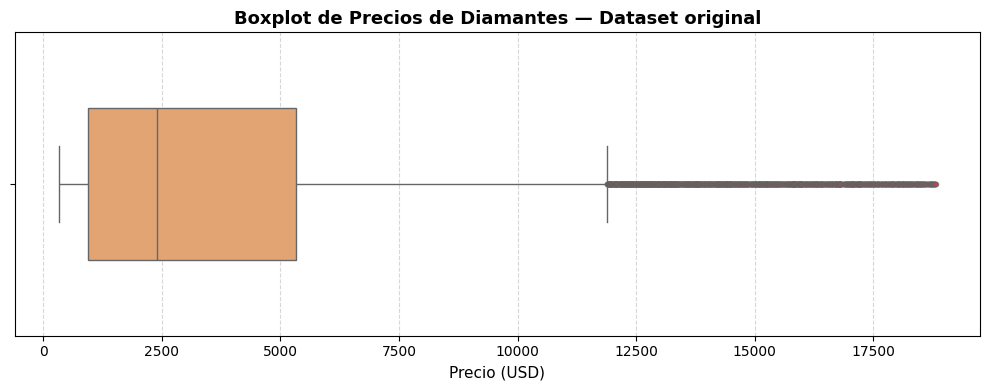

→ Los puntos a la derecha del bigote superior representan posibles outliers.


In [13]:
# Cargar dataset Diamonds
df2 = sns.load_dataset("diamonds")

print(f"Shape del dataset Diamonds: {df2.shape}")
print(f"\nEstadísticas de 'price':")
print(df2['price'].describe().to_string())

# Boxplot de precios
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df2["price"], ax=ax, color="#f4a261", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=3, alpha=0.4))
ax.set_title("Boxplot de Precios de Diamantes — Dataset original", fontsize=13, fontweight='bold')
ax.set_xlabel("Precio (USD)", fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("→ Los puntos a la derecha del bigote superior representan posibles outliers.")

Q1 = $950  |  Q3 = $5,324  |  IQR = $4,374
Límite inferior: $-5,611
Límite superior: $11,886

Outliers detectados: 3540 (6.6% del dataset)
Precio mínimo de outliers: $11,886
Precio máximo de outliers: $18,823

Antes: 53940 filas  |  Después: 50400 filas  |  Eliminadas: 3540

Comparación estadística antes vs. después
          Antes   Después
count  53940.00  50400.00
mean    3932.80   3159.46
std     3989.44   2764.70
min      326.00    326.00
25%      950.00    911.00
50%     2401.00   2155.00
75%     5324.25   4669.00
max    18823.00  11883.00


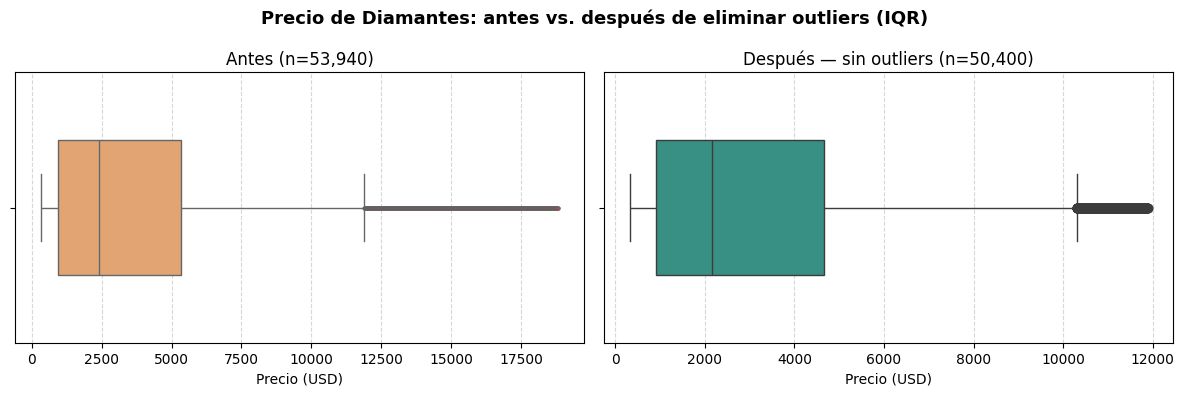

In [14]:
# Cálculo del IQR y filtrado de outliers
Q1 = df2["price"].quantile(0.25)
Q3 = df2["price"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 = ${Q1:,.0f}  |  Q3 = ${Q3:,.0f}  |  IQR = ${IQR:,.0f}")
print(f"Límite inferior: ${limite_inferior:,.0f}")
print(f"Límite superior: ${limite_superior:,.0f}")

# Detectar outliers
outliers = df2[(df2["price"] < limite_inferior) | (df2["price"] > limite_superior)]
print(f"\nOutliers detectados: {len(outliers)} ({len(outliers)/len(df2)*100:.1f}% del dataset)")
print(f"Precio mínimo de outliers: ${outliers['price'].min():,.0f}")
print(f"Precio máximo de outliers: ${outliers['price'].max():,.0f}")

# Filtrar valores dentro de los límites
df2_cleaned = df2[(df2["price"] >= limite_inferior) & (df2["price"] <= limite_superior)].copy()

print(f"\nAntes: {len(df2)} filas  |  Después: {len(df2_cleaned)} filas  |  Eliminadas: {len(df2) - len(df2_cleaned)}")

# Comparación de distribuciones
print("\nComparación estadística antes vs. después")
comparacion = pd.DataFrame({
    'Antes': df2['price'].describe(),
    'Después': df2_cleaned['price'].describe()
}).round(2)
print(comparacion.to_string())

# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Precio de Diamantes: antes vs. después de eliminar outliers (IQR)",
             fontsize=13, fontweight='bold')

sns.boxplot(x=df2["price"], ax=axes[0], color="#f4a261", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=2, alpha=0.3))
axes[0].set_title(f"Antes (n={len(df2):,})")
axes[0].set_xlabel("Precio (USD)")
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.boxplot(x=df2_cleaned["price"], ax=axes[1], color="#2a9d8f", width=0.5)
axes[1].set_title(f"Después — sin outliers (n={len(df2_cleaned):,})")
axes[1].set_xlabel("Precio (USD)")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Explicación del impacto en un modelo de Machine Learning

#### ¿Por qué se eligió el método IQR?

El método IQR (Rango Intercuartílico) es robusto porque:
- **No asume normalidad** en la distribución, a diferencia del z-score (que requiere distribución normal).
- Es **resistente a los propios outliers**: los cuartiles Q1 y Q3 no se ven afectados por valores extremos, mientras que la media sí.
- Es el método estándar visualizado en los boxplots, facilitando la interpretación.

#### Impacto de la eliminación en un modelo de Machine Learning

**Efectos positivos:**
- Algoritmos como **regresión lineal** y **KNN** son muy sensibles a valores extremos; eliminarlos mejora la estabilidad y reduce el error cuadrático medio (MSE) en el rango de precios más común.
- Reduce la varianza del modelo y mejora la generalización para diamantes de precio intermedio.

**Efectos negativos:**
- El modelo entrenado sin outliers **no podrá predecir correctamente** el precio de diamantes de lujo (precio > ~$11,000), ya que esos datos fueron eliminados del entrenamiento.
- Se pierde información relevante: los diamantes de precio alto son datos reales, no errores de medición.
- En este dataset, los "outliers" son diamantes de alta calidad (quilates elevados, corte ideal), que representan un segmento de mercado legítimo.

**Conclusión:** En el contexto de predicción de precios de diamantes, eliminar outliers es **contraproducente** para el objetivo de negocio. Sería más apropiado transformar la variable (ej: `log(price)`) para comprimir la escala sin perder datos.

### Preguntas de Reflexión — Sección 2

**1. ¿Cómo cambia la distribución de `price` después de eliminar outliers?**

La distribución se comprime significativamente:
- El **rango** pasa de $326–$18,823 a un intervalo más estrecho (hasta el límite superior del IQR ≈ $11,000 aproximadamente).
- La **media** disminuye considerablemente, acercándose a la mediana, lo que indica que la distribución resultante es más simétrica.
- La **desviación estándar** se reduce, reflejando menor dispersión.
- En el boxplot post-filtrado ya no se observan bigotes extendidos ni puntos aislados, lo que confirma que se eliminaron los valores más extremos de la cola derecha.

---

**2. ¿Eliminar outliers mejora siempre un análisis? ¿Cuándo puede ser contraproducente?**

No, no siempre es beneficioso. La decisión depende del contexto:

| Situación | ¿Eliminar? | Justificación |
|-----------|-----------|---------------|
| Error de entrada (ej: edad = 999) | Sí | No representa datos reales |
| Sensor defectuoso | Sí | Ruido instrumental, no fenómeno real |
| Diamante de lujo (precio = $18,000) | No | Dato real, segmento de mercado legítimo |
| Modelo que debe predecir todo el rango | No | Eliminar sesgará las predicciones extremas |
| Análisis de segmento medio (no lujo) | Sí | Si el objetivo explícito excluye ese rango |

Eliminar outliers es **contraproducente** cuando: los valores extremos son datos legítimos, cuando el modelo debe generalizar a todo el rango, o cuando los outliers representan el fenómeno de interés (fraudes, fallos, eventos raros).

---

**3. ¿Existen casos en los que los outliers pueden ser la parte más importante de los datos?**

Sí, hay múltiples contextos donde los outliers son el objeto central del análisis:

- **Detección de fraude bancario:** Las transacciones fraudulentas son, por definición, atípicas. Eliminar outliers significaría eliminar exactamente lo que se quiere detectar.
- **Control de calidad industrial:** Los valores extremos en medidas de un producto señalan defectos de fabricación o piezas fuera de tolerancia — la parte más crítica a monitorear.
- **Epidemiología:** Un brote infeccioso aparece como un pico estadístico (outlier) en la tasa de casos. Filtrarlo borraría la señal de alerta temprana.
- **Astrofísica / astronomía:** Las supernovas, agujeros negros y eventos raros son outliers en las distribuciones de luminosidad; ignorarlos llevaría a modelos incompletos del universo.
- **Análisis de riesgo financiero:** Los eventos de cola ("cisne negro") — crisis del 2008, pandemia de 2020 — son exactamente los outliers que los modelos deben ser capaces de capturar.

---
## Sección 3: Transformación de Datos Numéricos y Categóricos

**Objetivo:** Aplicar transformación de datos numéricos y categóricos en un dataset real.

### Instrucciones
1. Cargar el dataset Titanic de Seaborn.
2. Aplicar normalización Min-Max en la columna `fare`.
3. Convertir la columna `sex` a valores numéricos usando One-Hot Encoding.
4. Explicar el impacto de esta transformación en un modelo de clasificación.

In [15]:
# Cargar dataset Titanic
df3 = sns.load_dataset("titanic")

print(f"Shape del dataset: {df3.shape}")
print(f"\nEstadísticas de 'fare' (antes de normalizar):")
print(df3['fare'].describe().to_string())

# Normalización Min-Max de la columna 'fare'
scaler = MinMaxScaler()
df3["fare_normalizado"] = scaler.fit_transform(df3[["fare"]])

print(f"\n Normalización Min-Max aplicada a 'fare'")
print(f"Rango original: [{df3['fare'].min():.2f}, {df3['fare'].max():.2f}]")
print(f"Rango normalizado: [{df3['fare_normalizado'].min():.4f}, {df3['fare_normalizado'].max():.4f}]")
print("\nComparación de los primeros 5 registros:")
print(df3[["fare", "fare_normalizado"]].head().to_string())

Shape del dataset: (891, 15)

Estadísticas de 'fare' (antes de normalizar):
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200

 Normalización Min-Max aplicada a 'fare'
Rango original: [0.00, 512.33]
Rango normalizado: [0.0000, 1.0000]

Comparación de los primeros 5 registros:
      fare  fare_normalizado
0   7.2500          0.014151
1  71.2833          0.139136
2   7.9250          0.015469
3  53.1000          0.103644
4   8.0500          0.015713


Valores únicos en 'sex' antes del encoding: ['male', 'female']
Distribución:
sex
male      577
female    314

=== Resultado del One-Hot Encoding ===
Nuevas columnas creadas: Sexo_female, Sexo_male

Datos transformados (primeras 10 filas):
      fare  fare_normalizado  Sexo_female  Sexo_male
0   7.2500          0.014151            0          1
1  71.2833          0.139136            1          0
2   7.9250          0.015469            1          0
3  53.1000          0.103644            1          0
4   8.0500          0.015713            0          1
5   8.4583          0.016510            0          1
6  51.8625          0.101229            0          1
7  21.0750          0.041136            0          1
8  11.1333          0.021731            1          0
9  30.0708          0.058694            1          0


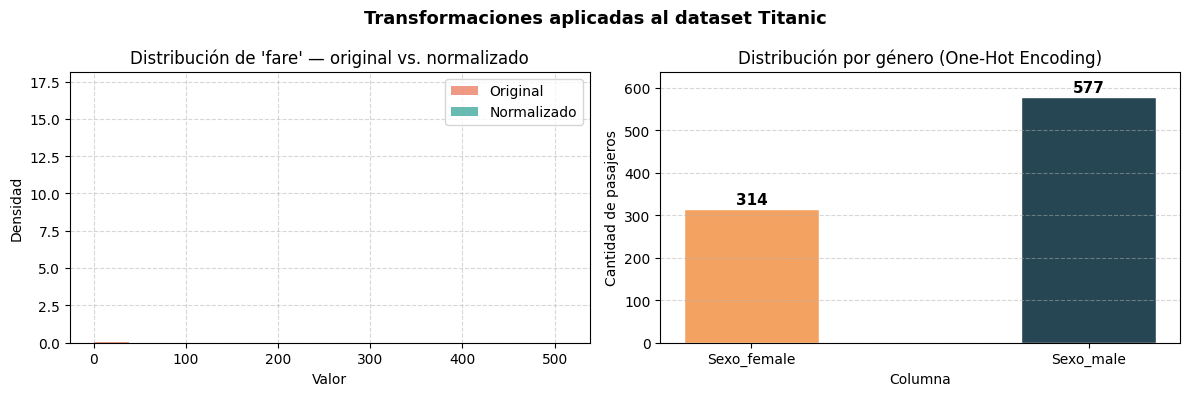

In [16]:
# One-Hot Encoding de la columna 'sex'
print("Valores únicos en 'sex' antes del encoding:", df3['sex'].unique().tolist())
print(f"Distribución:\n{df3['sex'].value_counts().to_string()}")

df3 = pd.get_dummies(df3, columns=["sex"], prefix="Sexo", dtype=int)

print("\n=== Resultado del One-Hot Encoding ===")
print("Nuevas columnas creadas: Sexo_female, Sexo_male")
print("\nDatos transformados (primeras 10 filas):")
print(df3[["fare", "fare_normalizado", "Sexo_female", "Sexo_male"]].head(10).to_string())

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Transformaciones aplicadas al dataset Titanic", fontsize=13, fontweight='bold')

# Distribución de fare antes y después
axes[0].hist(df3['fare'], bins=40, color='#e76f51', alpha=0.7, label='Original', density=True)
axes[0].hist(df3['fare_normalizado'], bins=40, color='#2a9d8f', alpha=0.7, label='Normalizado', density=True)
axes[0].set_title("Distribución de 'fare' — original vs. normalizado")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.5)

# Conteo de One-Hot Encoding
conteo = df3[['Sexo_female', 'Sexo_male']].sum()
bars = axes[1].bar(conteo.index, conteo.values, color=['#f4a261', '#264653'], width=0.4, edgecolor='white')
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(val)), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Distribución por género (One-Hot Encoding)")
axes[1].set_xlabel("Columna")
axes[1].set_ylabel("Cantidad de pasajeros")
axes[1].set_ylim(0, conteo.max() + 60)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Explicación del impacto en un modelo de clasificación

#### Normalización Min-Max en `fare`

La fórmula aplicada es:
$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Impacto en clasificación:**
- **Algoritmos basados en distancia** (KNN, SVM con kernel RBF): sin normalizar, `fare` (rango $0–$512) dominaría completamente sobre `age` (rango 0–80) al calcular distancias euclídeas. Con Min-Max, ambas variables contribuyen proporcionalmente.
- **Regresión logística con regularización (L1/L2):** Los coeficientes regularizados son comparables entre variables solo si están en la misma escala.
- **Árboles de decisión y Random Forest:** No se ven afectados por la escala (usan umbrales), por lo que la normalización es irrelevante para ellos.
- **Redes neuronales:** La normalización acelera la convergencia del gradiente descendente y mejora la estabilidad numérica.

**Importante:** Min-Max es sensible a outliers. Un pasajero con `fare = $512` define el máximo, comprimiendo el resto de los valores cerca de 0. En presencia de outliers extremos, la estandarización Z-score puede ser más robusta.

---

#### One-Hot Encoding en `sex`

**Impacto en clasificación:**
- Transforma la variable categórica en un formato que los algoritmos matemáticos pueden procesar directamente.
- Crea dos columnas binarias: `Sexo_female` y `Sexo_male`, donde cada pasajero tiene 1 en la columna correspondiente y 0 en la otra.
- En la práctica, con solo dos categorías se puede usar `drop_first=True` para evitar la **trampa de la variable dummy** (multicolinealidad perfecta): `Sexo_female = 1 - Sexo_male`, haciendo una columna redundante.
- Para modelos de árboles esto no es problema, pero sí para regresión logística.

### Preguntas de Reflexión — Sección 3

**1. ¿Por qué One-Hot Encoding es mejor que Label Encoding en este caso?**

`sex` es una variable **categórica nominal** (sin orden intrínseco entre "female" y "male"). Si aplicáramos Label Encoding:
- `female = 0`, `male = 1`

Esto implicaría que "male" es matemáticamente "mayor" que "female" por una unidad. Algoritmos como la regresión logística o KNN interpretarían esa diferencia numérica como una relación ordinal inexistente, generando **coeficientes o distancias sesgadas**.

One-Hot Encoding, en cambio:
- Crea columnas binarias independientes sin imponer ningún orden.
- Permite que el modelo aprenda el efecto de cada categoría de forma independiente.
- Es el estándar para variables nominales en la mayoría de los algoritmos de ML.

**Excepción:** Algoritmos como Gradient Boosting o LightGBM pueden manejar variables categóricas directamente con Label Encoding sin introducir sesgos, por su naturaleza de árboles.

---

**2. ¿Cómo cambiaría el rendimiento de un modelo si usamos datos sin normalizar?**

Depende del algoritmo:

| Algoritmo | Sin normalizar | Con normalización |
|-----------|---------------|-------------------|
| KNN | Dominado por `fare` (rango amplio); predicciones erróneas | Contribución equitativa de todas las variables |
| Regresión Logística (con L2) | Regularización penaliza desigualmente; coeficientes inestables | Regularización equilibrada |
| SVM (kernel RBF) | Convergencia lenta o incorrecta | Convergencia rápida y correcta |
| Random Forest / XGBoost | Sin cambio significativo | Sin cambio significativo |
| Red Neuronal | Gradientes desbalanceados; convergencia lenta | Gradientes estables; entrenamiento eficiente |

En la práctica, para el Titanic con KNN o regresión logística, no normalizar `fare` llevaría a que el modelo ignore efectivamente variables como `age` o `pclass` al calcular similitudes.

---

**3. ¿Cuándo puede ser preferible usar una codificación ordinal?**

La codificación ordinal (OrdinalEncoder) es preferible cuando la variable tiene una **jerarquía semántica real y demostrable**:

- **`pclass` en Titanic (1ª, 2ª, 3ª clase):** Hay un orden claro de nivel socioeconómico y condiciones de viaje. Codificar como 1, 2, 3 preserva esa jerarquía.
- **Nivel educativo** (Primaria < Secundaria < Universitario < Posgrado): El orden refleja años de formación acumulados.
- **Satisfacción del cliente** (Muy insatisfecho < Insatisfecho < Neutral < Satisfecho < Muy satisfecho): Escala Likert con orden claro.
- **Talla de ropa** (XS < S < M < L < XL): Orden de tamaño inequívoco.

**Ventaja adicional:** La codificación ordinal genera una sola columna en lugar de N-1 columnas (One-Hot), lo que es relevante cuando la variable tiene muchas categorías, evitando la **maldición de la dimensionalidad**.

### Conclusión general

El preprocesamiento de datos no es un paso mecánico: cada decisión (eliminar vs. imputar, IQR vs. z-score, One-Hot vs. ordinal) tiene implicaciones directas sobre la calidad, el sesgo y la utilidad de los modelos resultantes. La clave es entender el **contexto del dominio** (¿qué representa cada variable?) y el **objetivo del análisis** (¿qué tipo de modelo se usará?) para elegir la técnica más adecuada en cada caso.